## Opinion Fitting with Fixed Graph Models

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

from data_prep import (
    load_run_data,
    build_global_init_map,
    build_run_trajectory,
    build_neighbors_index,
    _numeric_agent_key,
)
from analysis_utils import (
    align_rollout_pair,
    compute_mean_prediction_error,
    compute_max_prediction_error,
    evaluate_validation_model_by_run,
    plot_mean_per_timestep,
    plot_variance_per_timestep,
    plot_wasserstein_distance_per_timestep,
    plot_observed_trajectories,
    plot_predicted_vs_observed,
    plot_box_per_timestep,
    plot_violin_per_timestep,
)
from fixed_graph.degroot import fit_row_stochastic_W_from_pooled_runs, degroot_rollout_prediction
from fixed_graph.friedkin_johnsen import (
    select_friedkin_johnsen_lambdas,
    fit_friedkin_johnsen,
    friedkin_johnsen_rollout_prediction,
)
from fixed_graph.homophily import (
    fit_fg_homophily,
    rollout_fg_homophily,
    fit_fg_fj_homophily,
    rollout_fg_fj_homophily,
    fit_fg_fj_bias_homophily,
    rollout_fg_fj_bias_homophily,
)

ROOT = Path('..').resolve()
TRAIN_ROOT = ROOT / 'cleaned_data'
TEST_ROOT = ROOT / 'init_conditions'

PARAMS = {
    'target_agent_fraction': 0.4,
    'constrain_messages': 150,
    'rollout_horizon_cap': 20,
    'validation_horizon': 8,
}

print('Project root:', ROOT)
print('Training runs root:', TRAIN_ROOT)
print('Validation runs root:', TEST_ROOT)

Project root: /Users/samuelli/Documents/code/llm/llm-network/modeling
Training runs root: /Users/samuelli/Documents/code/llm/llm-network/modeling/cleaned_data
Validation runs root: /Users/samuelli/Documents/code/llm/llm-network/modeling/init_conditions


## Data Construction

- Each run is mapped to a shared global agent index.
- Trajectories use the same preprocessing as the adjacency notebook.
- The fixed-graph fits pool runs only when their neighbor topology matches.

In [2]:
TRAIN_RUN_DIRS = sorted([p for p in TRAIN_ROOT.iterdir() if p.is_dir()])
TRAIN_DATA = {r.name: load_run_data(r) for r in TRAIN_RUN_DIRS}
GLOBAL_AGENT_IDS = sorted({a for d in TRAIN_DATA.values() for a in d['agent_ids']}, key=_numeric_agent_key)
N = len(GLOBAL_AGENT_IDS)

GLOBAL_INIT_BY_AGENT = build_global_init_map(TRAIN_DATA, GLOBAL_AGENT_IDS)
GLOBAL_INIT_VECTOR = np.asarray([GLOBAL_INIT_BY_AGENT[aid] for aid in GLOBAL_AGENT_IDS], dtype=float)

TRAIN_TRAJ_AND_MASK = {
    rn: build_run_trajectory(
        d,
        GLOBAL_AGENT_IDS,
        target_agent_fraction=PARAMS['target_agent_fraction'],
        return_post_mask=True,
        constrain_messages=PARAMS['constrain_messages'],
    )
    for rn, d in TRAIN_DATA.items()
}
TRAIN_TRAJ = {rn: tm[0] for rn, tm in TRAIN_TRAJ_AND_MASK.items()}
TRAIN_POST_MASK = {rn: tm[1] for rn, tm in TRAIN_TRAJ_AND_MASK.items()}
TRAIN_NEIGHBORS = {rn: build_neighbors_index(d, GLOBAL_AGENT_IDS) for rn, d in TRAIN_DATA.items()}

print('Global agent count:', N)
print('Global init priors available:', len(GLOBAL_INIT_BY_AGENT))
for rn in sorted(TRAIN_TRAJ.keys()):
    tr = TRAIN_TRAJ[rn]
    print(f'{rn}: trajectory shape={tr.shape}, horizon={tr.shape[0] - 1}')

total_edges = sum(len(nbrs) for nbrs in TRAIN_NEIGHBORS[TRAIN_RUN_DIRS[0].name].values())

Global agent count: 30
Global init priors available: 30
run_20260320-130058: trajectory shape=(9, 30), horizon=8
run_20260320-133304: trajectory shape=(12, 30), horizon=11
run_20260320-140500: trajectory shape=(9, 30), horizon=8
run_20260320-143643: trajectory shape=(9, 30), horizon=8
run_20260320-150827: trajectory shape=(9, 30), horizon=8
run_20260320-154019: trajectory shape=(11, 30), horizon=10
run_20260320-161210: trajectory shape=(9, 30), horizon=8
run_20260320-164400: trajectory shape=(11, 30), horizon=10
run_20260320-171544: trajectory shape=(9, 30), horizon=8
run_20260320-174722: trajectory shape=(10, 30), horizon=9
run_20260321-121900: trajectory shape=(11, 30), horizon=10
run_20260321-125108: trajectory shape=(10, 30), horizon=9
run_20260321-132251: trajectory shape=(8, 30), horizon=7
run_20260321-135440: trajectory shape=(12, 30), horizon=11
run_20260321-142622: trajectory shape=(10, 30), horizon=9
run_20260321-145803: trajectory shape=(10, 30), horizon=9
run_20260321-15293

Training curve horizon (shared): 5
DeGroot pooled MSE: 0.025754995811714417
FJ lambda1 / lambda2 / bias: 0.05 0.23947368421052628 0.4975695676791729
Homophily gamma: 20.886034987468406
Homophily+FJ gamma / lambda: 20.02397584154211 0.9272179809395018
Homophily+bias gamma / lambda1 / lambda2 / bias: 25.343057416650904 0.8179407049391146 0.08192770663582165 0.05052078051993705
Degroot


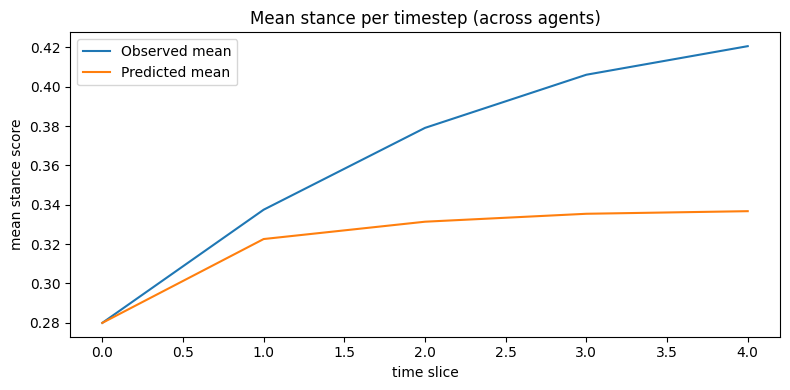

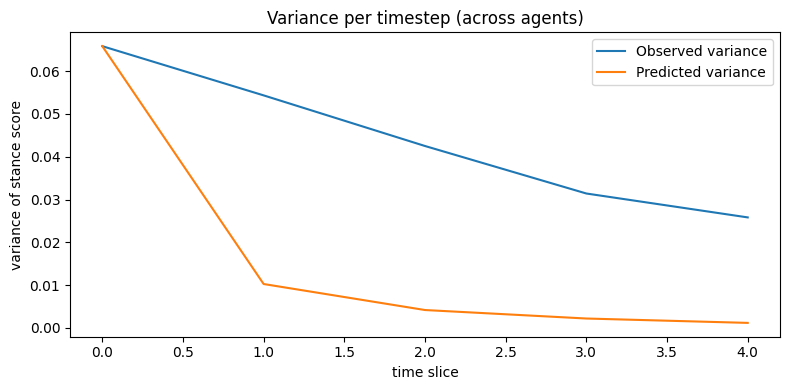

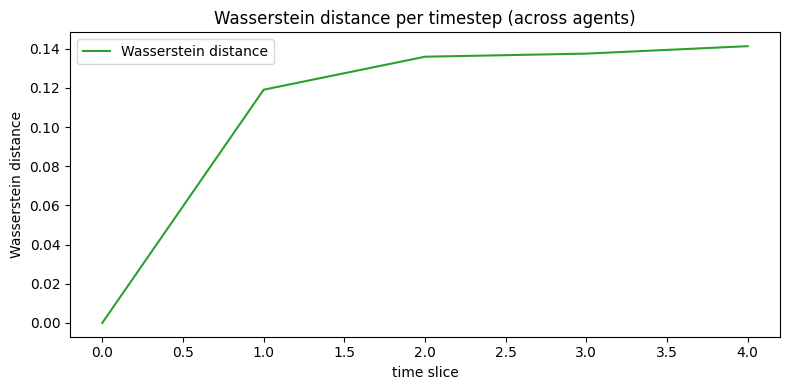

Friedkin-Johnsen


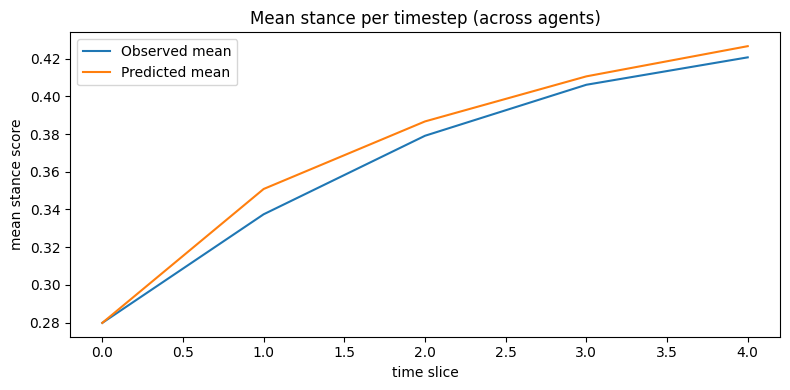

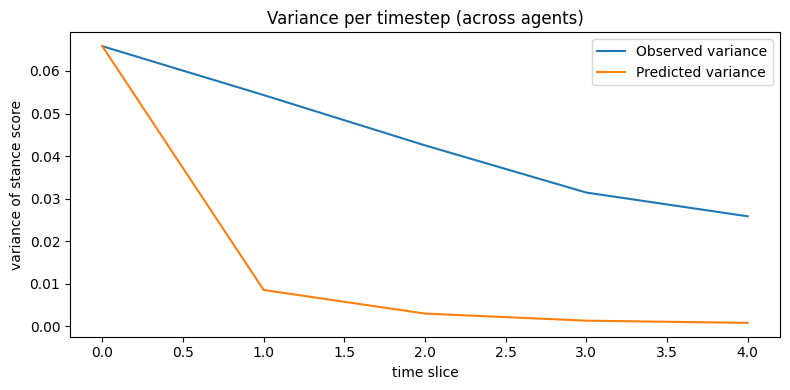

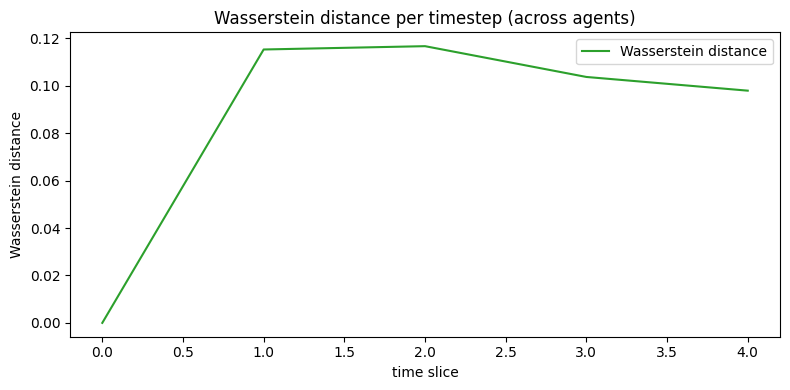

Homophily


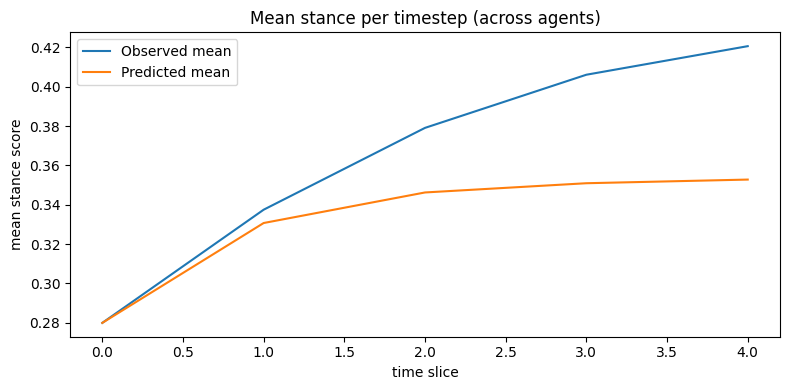

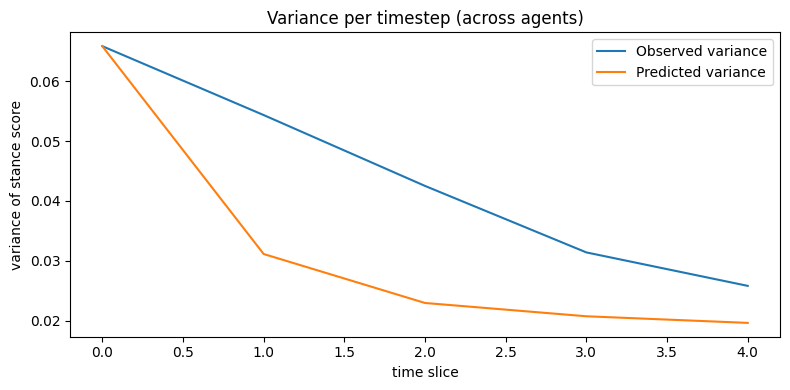

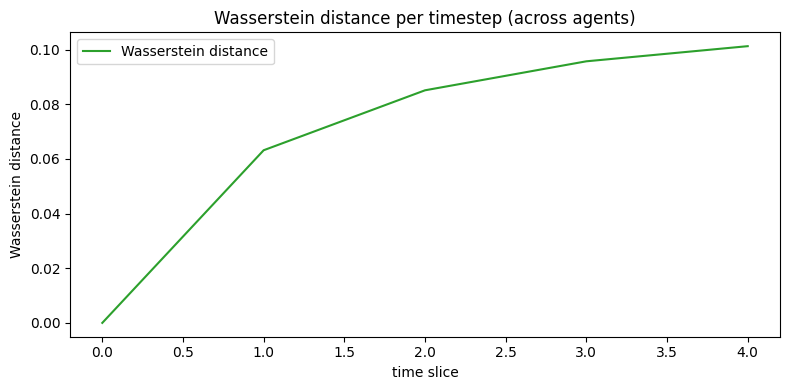

Homophily + FJ


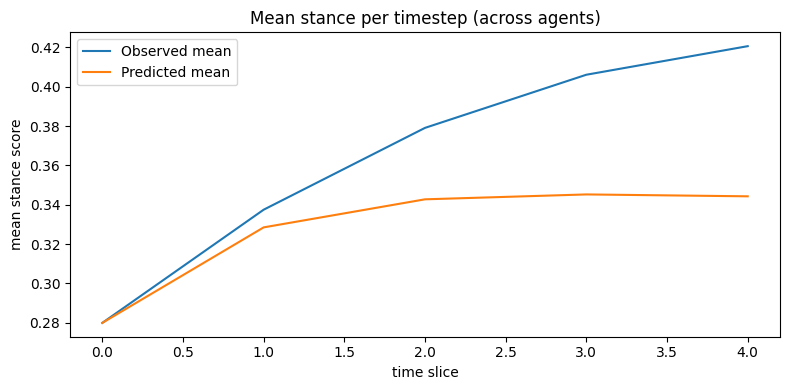

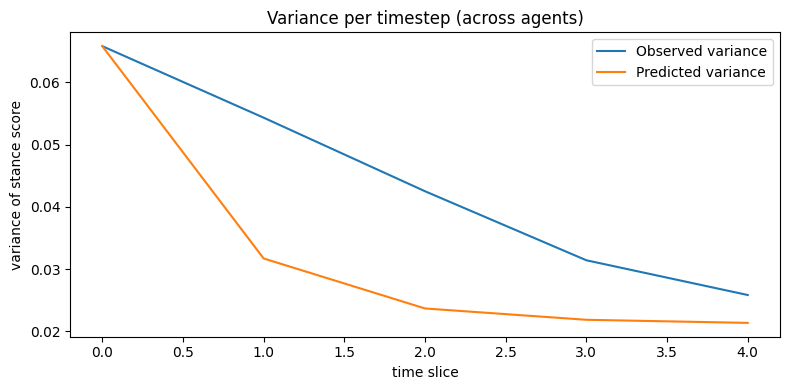

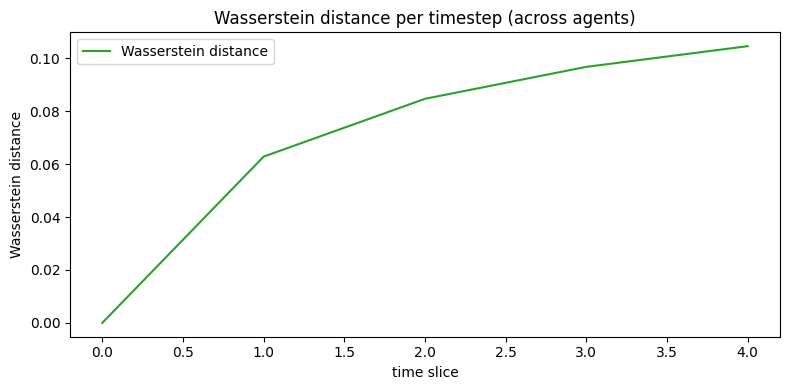

Homophily + bias


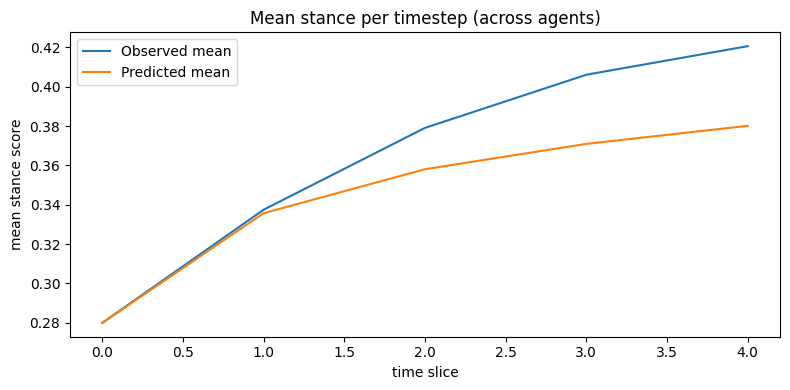

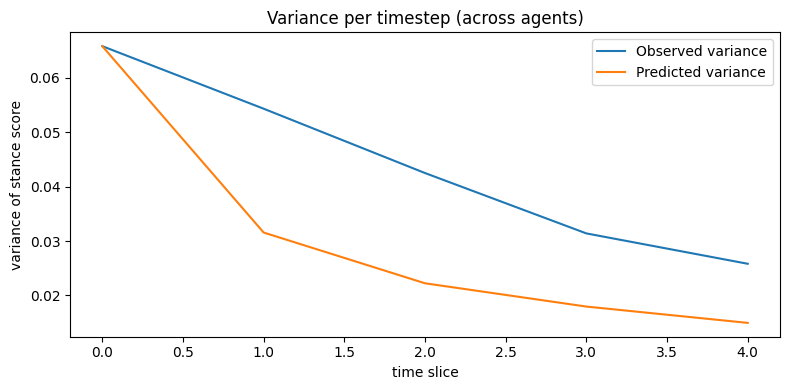

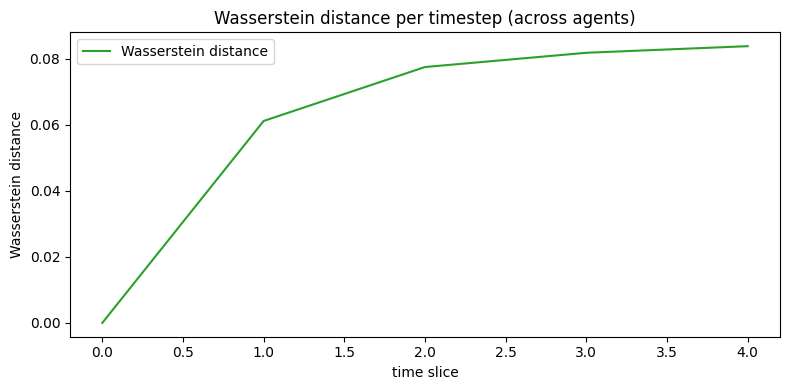

              model  pooled_mse  transition_mse_mean  mean_curve_abs_error  \
0           degroot    0.025755             0.031402              0.051523   
1  friedkin_johnsen    0.024793             0.022515              0.030783   
2         homophily    0.014303             0.033334              0.042982   
3      homophily_fj    0.013873             0.036054              0.045176   
4    homophily_bias    0.013946             0.024852              0.034659   

   var_curve_abs_error  wasserstein_curve_mean  
0             0.027249                0.106789  
1             0.028111                0.086769  
2             0.014920                0.069062  
3             0.014570                0.069755  
4             0.014661                0.060879  
              model  num_params  mean_abs_error  max_abs_error       mse_aic  \
0  friedkin_johnsen         183        0.098968       0.934299 -69848.856841   
1    homophily_bias         184        0.108327       0.896464 -67624.272903 

In [3]:
def flatten_eval_result(eval_result):
    obs_curves = []
    pred_curves = []
    for rn in sorted(eval_result['per_run'].keys()):
        observed = np.asarray(eval_result['per_run'][rn]['observed'], dtype=float)
        predicted = np.asarray(eval_result['per_run'][rn]['predicted'], dtype=float)
        observed, predicted = align_rollout_pair(observed, predicted)
        obs_curves.append(observed.ravel())
        pred_curves.append(predicted.ravel())
    return np.concatenate(obs_curves), np.concatenate(pred_curves)

DEGROOT_W, DEGROOT_X_POOL, DEGROOT_Y_POOL = fit_row_stochastic_W_from_pooled_runs(TRAIN_TRAJ, TRAIN_NEIGHBORS)
DEGROOT_POOL_MSE = float(np.mean((DEGROOT_Y_POOL - DEGROOT_X_POOL @ DEGROOT_W.T) ** 2))

LAMBDA_GRID = np.linspace(0.05, 0.95, 39)
BEST_FJ, FJ_GRID = select_friedkin_johnsen_lambdas(
    TRAIN_TRAJ,
    TRAIN_NEIGHBORS,
    LAMBDA_GRID,
    GLOBAL_INIT_BY_AGENT,
)
FJ_W, FJ_BIAS, FJ_X_POOL, FJ_Y_POOL = fit_friedkin_johnsen(
    TRAIN_TRAJ,
    TRAIN_NEIGHBORS,
    BEST_FJ['lambda1'],
    BEST_FJ['lambda2'],
    GLOBAL_INIT_BY_AGENT,
)
FJ_ALPHA = 1.0 - BEST_FJ['lambda1'] - BEST_FJ['lambda2']
FJ_POOL_MSE = float(np.mean((FJ_Y_POOL - (BEST_FJ['lambda1'] * GLOBAL_INIT_VECTOR[None, :] + BEST_FJ['lambda2'] * FJ_BIAS + FJ_ALPHA * (FJ_X_POOL @ FJ_W.T))) ** 2))

HOMO_FIT = fit_fg_homophily(TRAIN_TRAJ, TRAIN_NEIGHBORS, gamma0=1.0)
HOMO_FJ_FIT = fit_fg_fj_homophily(TRAIN_TRAJ, TRAIN_NEIGHBORS, gamma0=HOMO_FIT['gamma'])
HOMO_BIAS_FIT = fit_fg_fj_bias_homophily(TRAIN_TRAJ, TRAIN_NEIGHBORS, gamma0=HOMO_FIT['gamma'])

TRAIN_DEGROOT = evaluate_validation_model_by_run(
    TRAIN_TRAJ,
    lambda _rn, observed: degroot_rollout_prediction(
        DEGROOT_W,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
    ),
)
TRAIN_FJ = evaluate_validation_model_by_run(
    TRAIN_TRAJ,
    lambda _rn, observed: friedkin_johnsen_rollout_prediction(
        FJ_W,
        FJ_BIAS,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        BEST_FJ['lambda1'],
        BEST_FJ['lambda2'],
    ),
)
TRAIN_HOMO = evaluate_validation_model_by_run(
    TRAIN_TRAJ,
    lambda _rn, observed: rollout_fg_homophily(
        HOMO_FIT['W'],
        HOMO_FIT['gamma'],
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
    ),
)
TRAIN_HOMO_FJ = evaluate_validation_model_by_run(
    TRAIN_TRAJ,
    lambda _rn, observed: rollout_fg_fj_homophily(
        HOMO_FJ_FIT['W'],
        HOMO_FJ_FIT['gamma'],
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        lambda_homophily=HOMO_FJ_FIT['lambda_homophily'],
    ),
)
TRAIN_HOMO_BIAS = evaluate_validation_model_by_run(
    TRAIN_TRAJ,
    lambda _rn, observed: rollout_fg_fj_bias_homophily(
        HOMO_BIAS_FIT['W'],
        HOMO_BIAS_FIT['gamma'],
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        bias=HOMO_BIAS_FIT['bias'],
        lambda1=HOMO_BIAS_FIT['lambda1'],
        lambda2=HOMO_BIAS_FIT['lambda2'],
    ),
)

TRAIN_CURVE_HORIZON = min(
    TRAIN_DEGROOT['mean_true_stack'].shape[1],
    TRAIN_FJ['mean_true_stack'].shape[1],
    TRAIN_HOMO['mean_true_stack'].shape[1],
    TRAIN_HOMO_FJ['mean_true_stack'].shape[1],
    TRAIN_HOMO_BIAS['mean_true_stack'].shape[1],
)

print('Training curve horizon (shared):', TRAIN_CURVE_HORIZON)
print('DeGroot pooled MSE:', DEGROOT_POOL_MSE)
print('FJ lambda1 / lambda2 / bias:', BEST_FJ['lambda1'], BEST_FJ['lambda2'], FJ_BIAS)
print('Homophily gamma:', HOMO_FIT['gamma'])
print('Homophily+FJ gamma / lambda:', HOMO_FJ_FIT['gamma'], HOMO_FJ_FIT['lambda_homophily'])
print('Homophily+bias gamma / lambda1 / lambda2 / bias:', HOMO_BIAS_FIT['gamma'], HOMO_BIAS_FIT['lambda1'], HOMO_BIAS_FIT['lambda2'], HOMO_BIAS_FIT['bias'])

print('Degroot')
plot_mean_per_timestep(
    TRAIN_DEGROOT['mean_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_DEGROOT['mean_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TRAIN_DEGROOT['var_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_DEGROOT['var_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TRAIN_DEGROOT['wasserstein_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)

print('Friedkin-Johnsen')
plot_mean_per_timestep(
    TRAIN_FJ['mean_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_FJ['mean_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TRAIN_FJ['var_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_FJ['var_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TRAIN_FJ['wasserstein_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)

print('Homophily')
plot_mean_per_timestep(
    TRAIN_HOMO['mean_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_HOMO['mean_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TRAIN_HOMO['var_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_HOMO['var_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TRAIN_HOMO['wasserstein_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)

print('Homophily + FJ')
plot_mean_per_timestep(
    TRAIN_HOMO_FJ['mean_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_HOMO_FJ['mean_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TRAIN_HOMO_FJ['var_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_HOMO_FJ['var_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TRAIN_HOMO_FJ['wasserstein_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)

print('Homophily + bias')
plot_mean_per_timestep(
    TRAIN_HOMO_BIAS['mean_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_HOMO_BIAS['mean_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TRAIN_HOMO_BIAS['var_true_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
    TRAIN_HOMO_BIAS['var_pred_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TRAIN_HOMO_BIAS['wasserstein_stack'].mean(axis=0)[:TRAIN_CURVE_HORIZON],
)

train_summary = pd.DataFrame([
    {
        'model': 'degroot',
        'pooled_mse': DEGROOT_POOL_MSE,
        'transition_mse_mean': TRAIN_DEGROOT['transition_mse_mean'],
        'mean_curve_abs_error': TRAIN_DEGROOT['mean_curve_abs_error'],
        'var_curve_abs_error': TRAIN_DEGROOT['var_curve_abs_error'],
        'wasserstein_curve_mean': TRAIN_DEGROOT['wasserstein_curve_mean'],
    },
    {
        'model': 'friedkin_johnsen',
        'pooled_mse': FJ_POOL_MSE,
        'transition_mse_mean': TRAIN_FJ['transition_mse_mean'],
        'mean_curve_abs_error': TRAIN_FJ['mean_curve_abs_error'],
        'var_curve_abs_error': TRAIN_FJ['var_curve_abs_error'],
        'wasserstein_curve_mean': TRAIN_FJ['wasserstein_curve_mean'],
    },
    {
        'model': 'homophily',
        'pooled_mse': HOMO_FIT['mse_pool'],
        'transition_mse_mean': TRAIN_HOMO['transition_mse_mean'],
        'mean_curve_abs_error': TRAIN_HOMO['mean_curve_abs_error'],
        'var_curve_abs_error': TRAIN_HOMO['var_curve_abs_error'],
        'wasserstein_curve_mean': TRAIN_HOMO['wasserstein_curve_mean'],
    },
    {
        'model': 'homophily_fj',
        'pooled_mse': HOMO_FJ_FIT['mse_pool'],
        'transition_mse_mean': TRAIN_HOMO_FJ['transition_mse_mean'],
        'mean_curve_abs_error': TRAIN_HOMO_FJ['mean_curve_abs_error'],
        'var_curve_abs_error': TRAIN_HOMO_FJ['var_curve_abs_error'],
        'wasserstein_curve_mean': TRAIN_HOMO_FJ['wasserstein_curve_mean'],
    },
    {
        'model': 'homophily_bias',
        'pooled_mse': HOMO_BIAS_FIT['mse_pool'],
        'transition_mse_mean': TRAIN_HOMO_BIAS['transition_mse_mean'],
        'mean_curve_abs_error': TRAIN_HOMO_BIAS['mean_curve_abs_error'],
        'var_curve_abs_error': TRAIN_HOMO_BIAS['var_curve_abs_error'],
        'wasserstein_curve_mean': TRAIN_HOMO_BIAS['wasserstein_curve_mean'],
    },
])
print(train_summary)

train_eval_map = {
    'degroot': (TRAIN_DEGROOT, 0 + total_edges - N),
    'friedkin_johnsen': (TRAIN_FJ, 3 + total_edges - N),
    'homophily': (TRAIN_HOMO, 1 + total_edges - N),
    'homophily_fj': (TRAIN_HOMO_FJ, 2 + total_edges - N),
    'homophily_bias': (TRAIN_HOMO_BIAS, 4 + total_edges - N),
}

train_ablation_rows = []
for model_name, (eval_result, num_params) in train_eval_map.items():
    y_true_flat, y_pred_flat = flatten_eval_result(eval_result)
    mean_stats = compute_mean_prediction_error(y_true_flat, y_pred_flat, num_params=num_params)
    max_stats = compute_max_prediction_error(y_true_flat, y_pred_flat, num_params=num_params)
    train_ablation_rows.append({
        'model': model_name,
        'num_params': num_params,
        'mean_abs_error': mean_stats['mean_error'],
        'max_abs_error': max_stats['max_error'],
        'mse_aic': mean_stats['aic'],
        'mse_bic': mean_stats['bic'],
        'mae_aic': max_stats['aic'],
        'mae_bic': max_stats['bic'],
    })

train_ablation_aic_bic = pd.DataFrame(train_ablation_rows).sort_values('mse_aic').reset_index(drop=True)
print(train_ablation_aic_bic)

## Validation

- Hold-out runs are evaluated with the fixed-graph parameters fit on training runs.
- The final cell keeps the plot-and-diagnostics layout from the adjacency notebook.

Validation runs found: 8
run_20260414-015624 shape= (8, 30)
run_20260414-022745 shape= (9, 30)
run_20260414-025845 shape= (5, 30)
run_20260414-032928 shape= (8, 30)
run_20260414-040000 shape= (7, 30)
run_20260414-043038 shape= (10, 30)
run_20260414-050133 shape= (7, 30)
run_20260414-053206 shape= (9, 30)
Validation curve horizon (shared): 5
Degroot


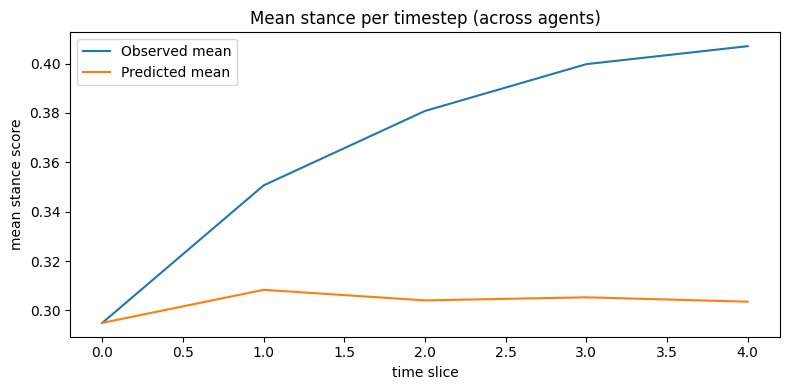

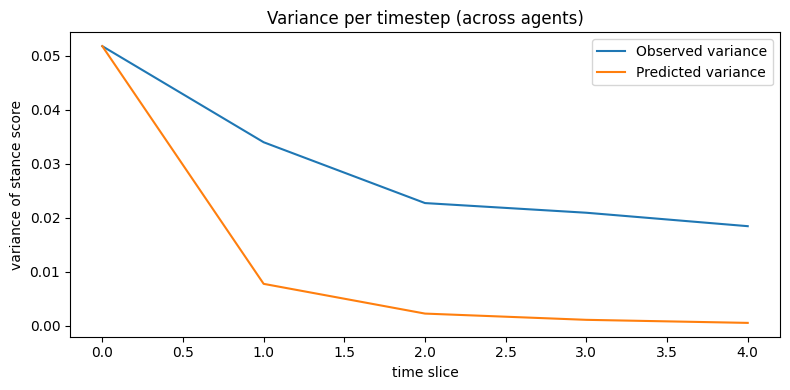

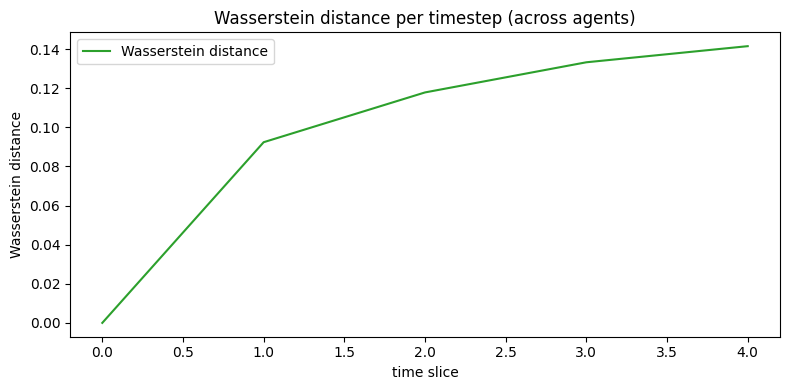

Friedkin-Johnsen


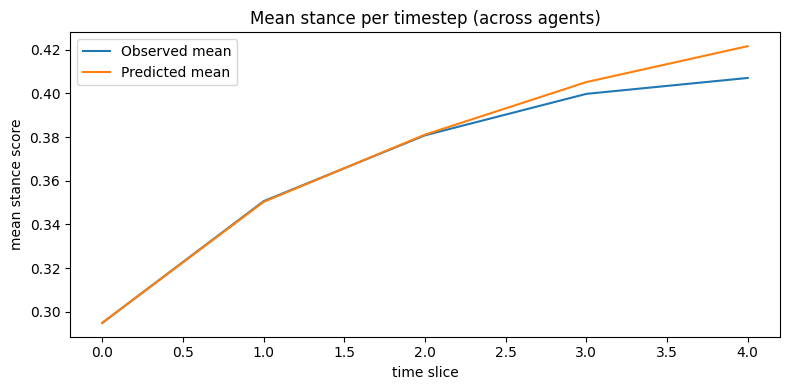

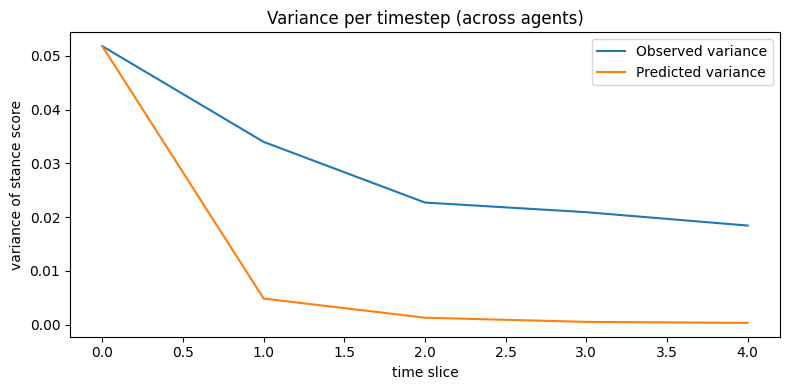

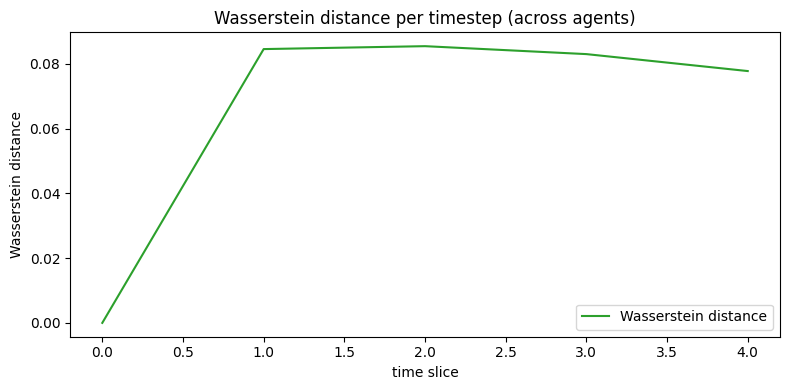

Homophily


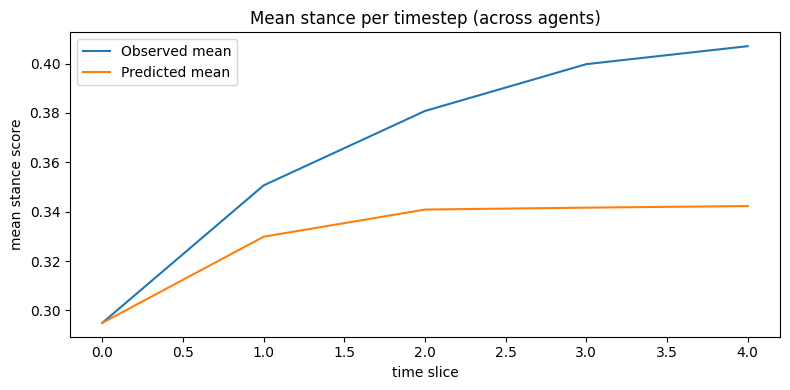

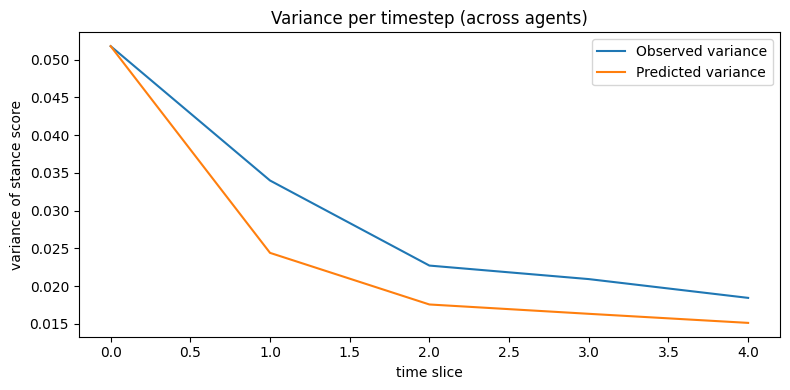

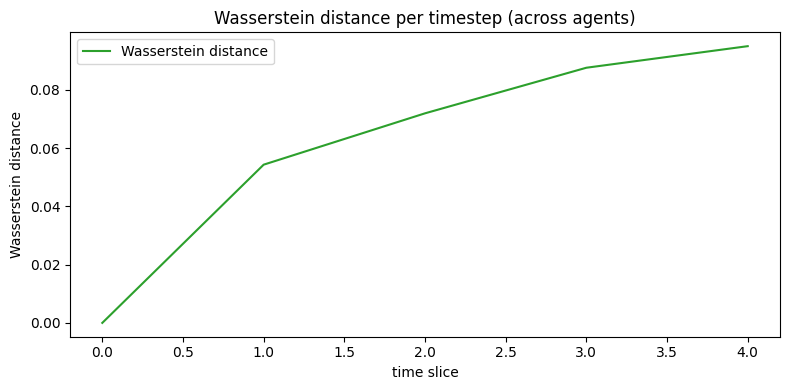

Homophily + FJ


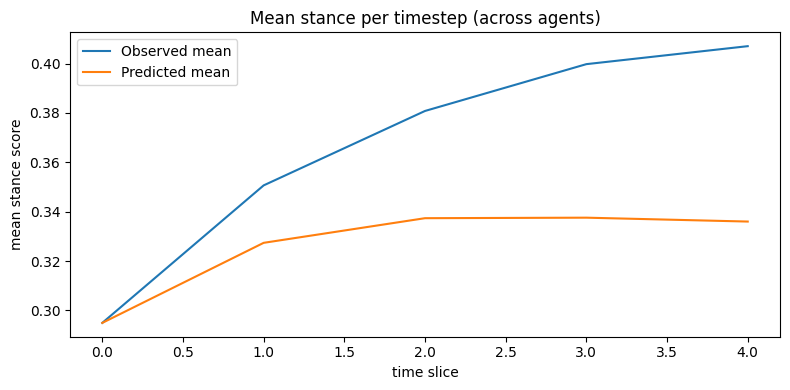

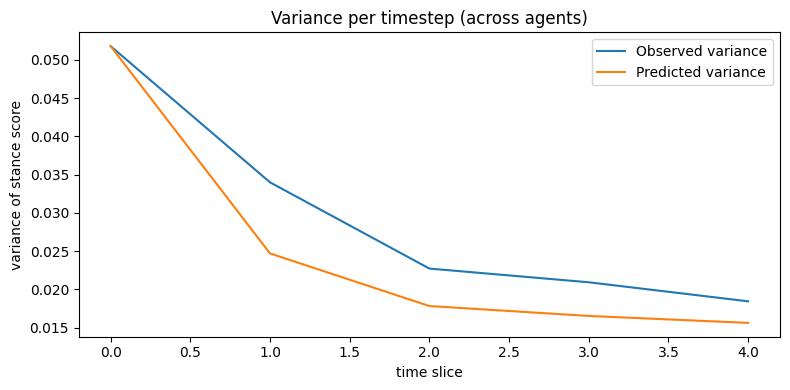

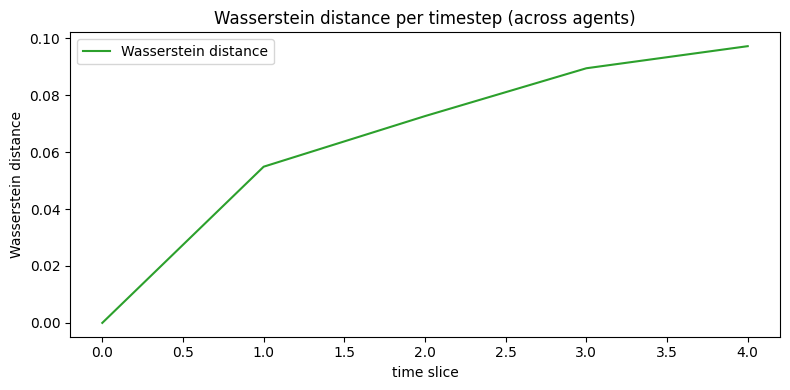

Homophily + bias


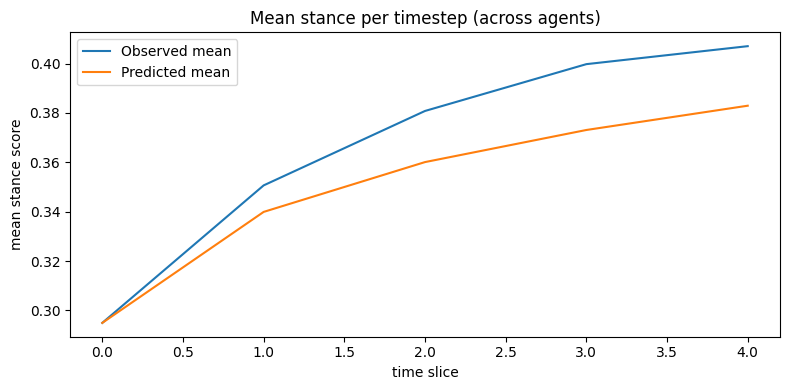

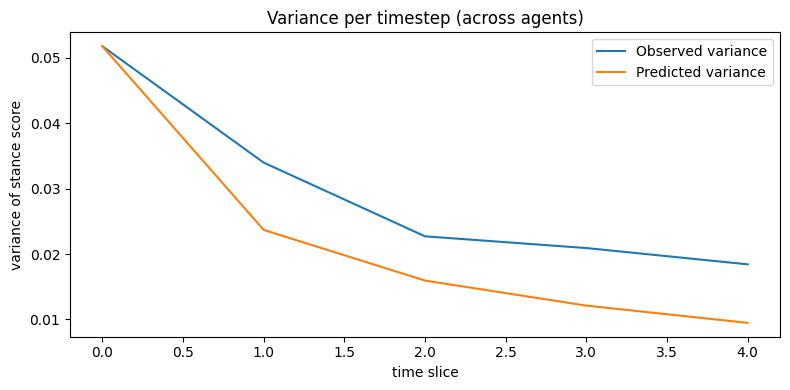

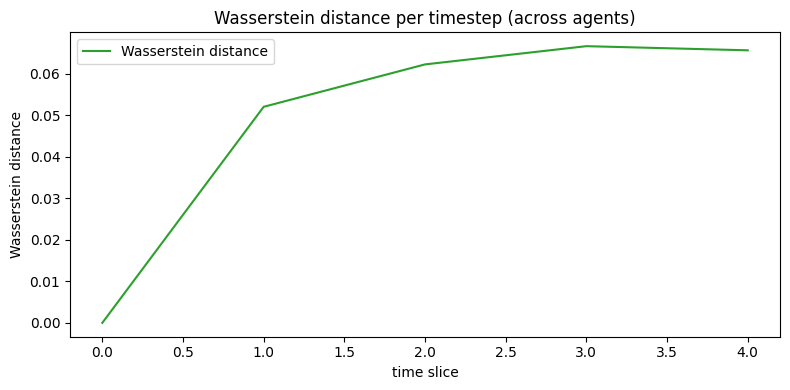

              model  transition_mse_mean  mean_curve_abs_error  \
0           degroot             0.027328              0.063561   
1  friedkin_johnsen             0.017075              0.018437   
2         homophily             0.027464              0.045748   
3      homophily_fj             0.028662              0.047551   
4    homophily_bias             0.020063              0.031338   

   var_curve_abs_error  wasserstein_curve_mean  
0             0.016901                0.097016  
1             0.017808                0.066146  
2             0.008926                0.061791  
3             0.009073                0.062861  
4             0.009835                0.049286  
              model  num_params  mean_abs_error  max_abs_error      mse_aic  \
0  friedkin_johnsen           3        0.085010       0.908733 -7645.347081   
1    homophily_bias           4        0.088882       0.826051 -7414.614137   
2         homophily           1        0.102792       0.867930 -6838.772

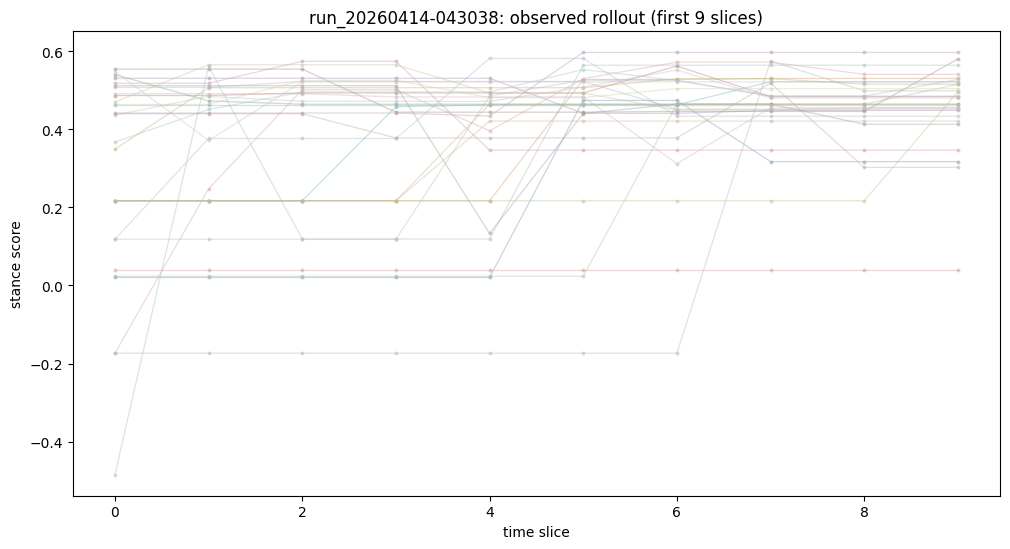

Per-trajectory diagnostics for model: degroot


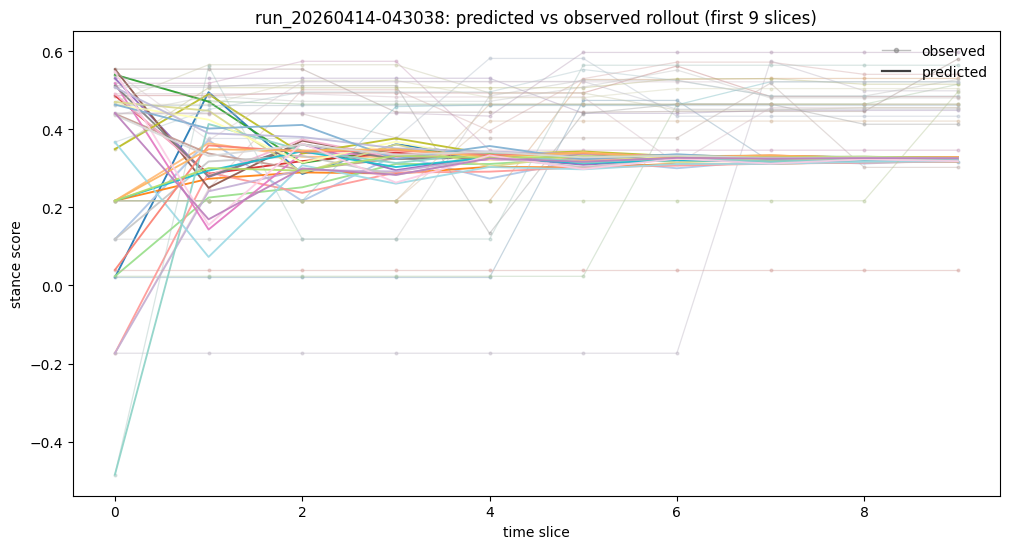

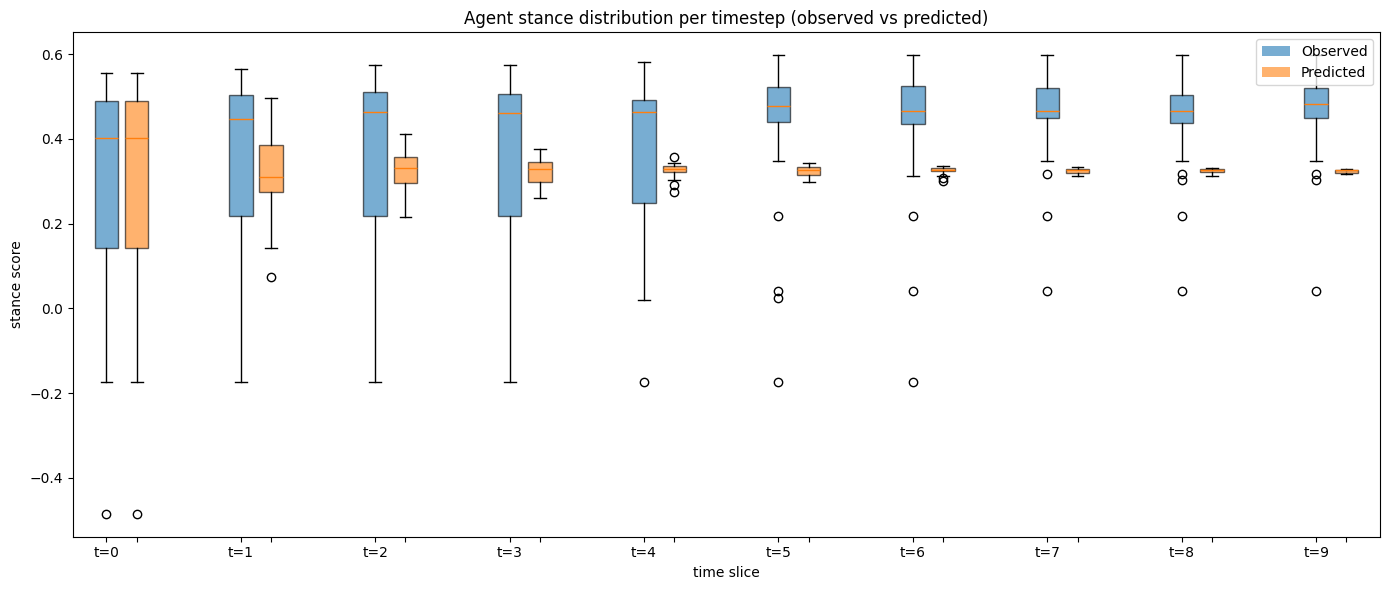

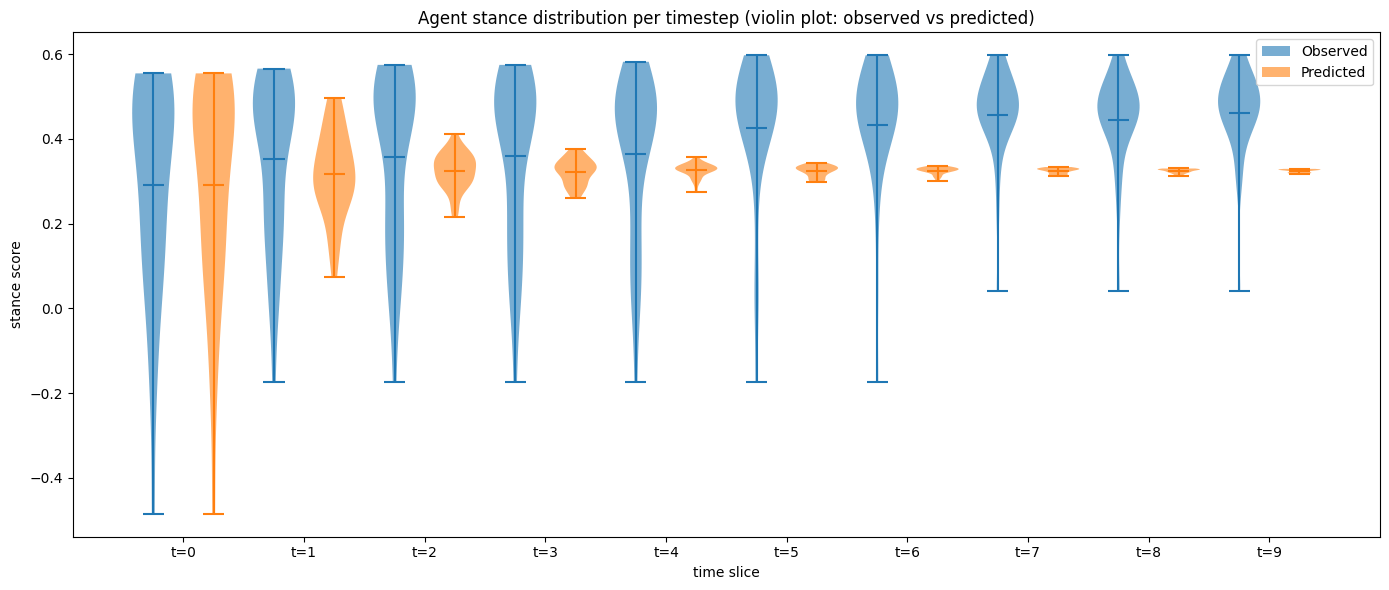

Per-trajectory diagnostics for model: friedkin_johnsen


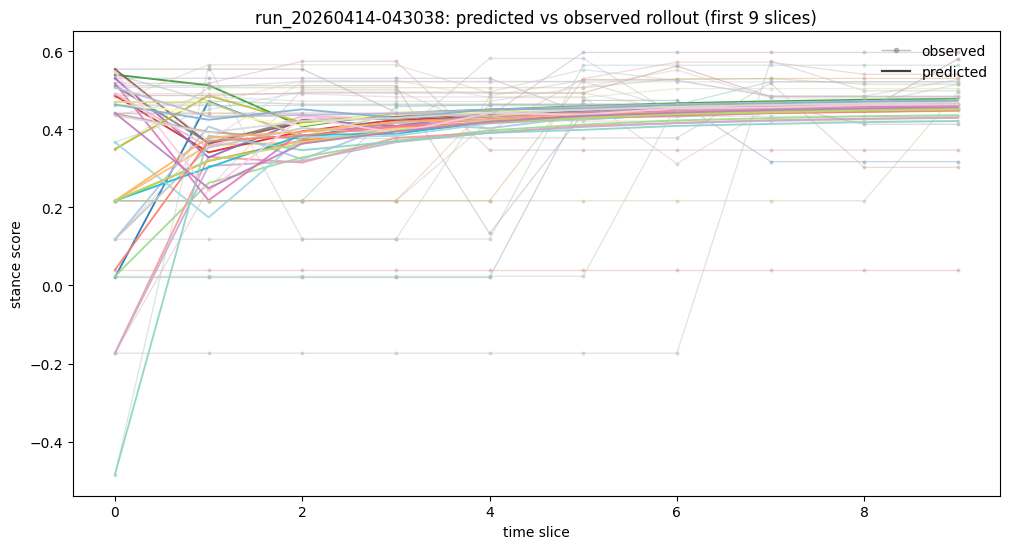

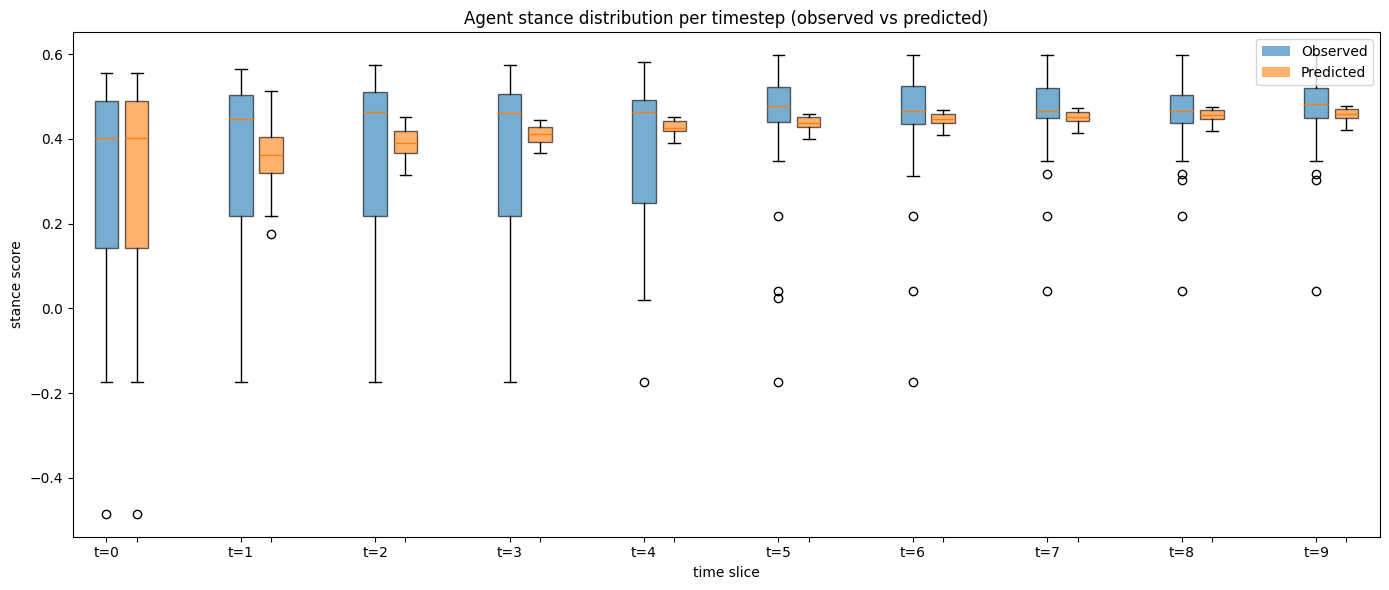

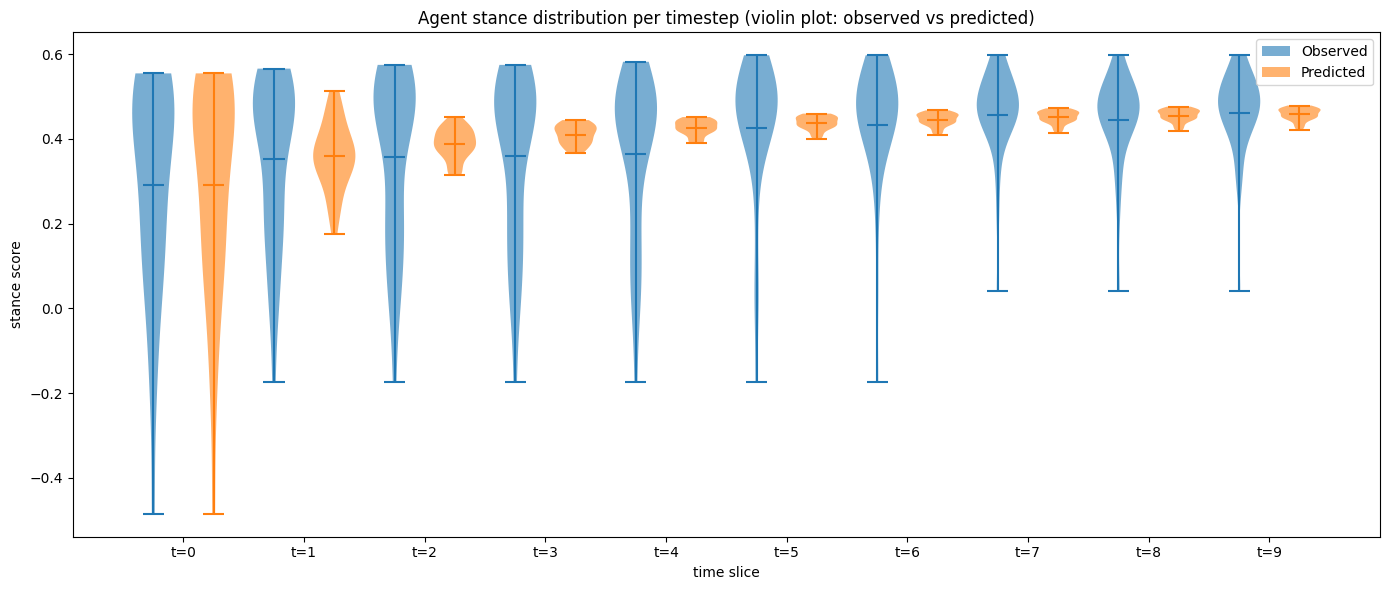

Per-trajectory diagnostics for model: homophily


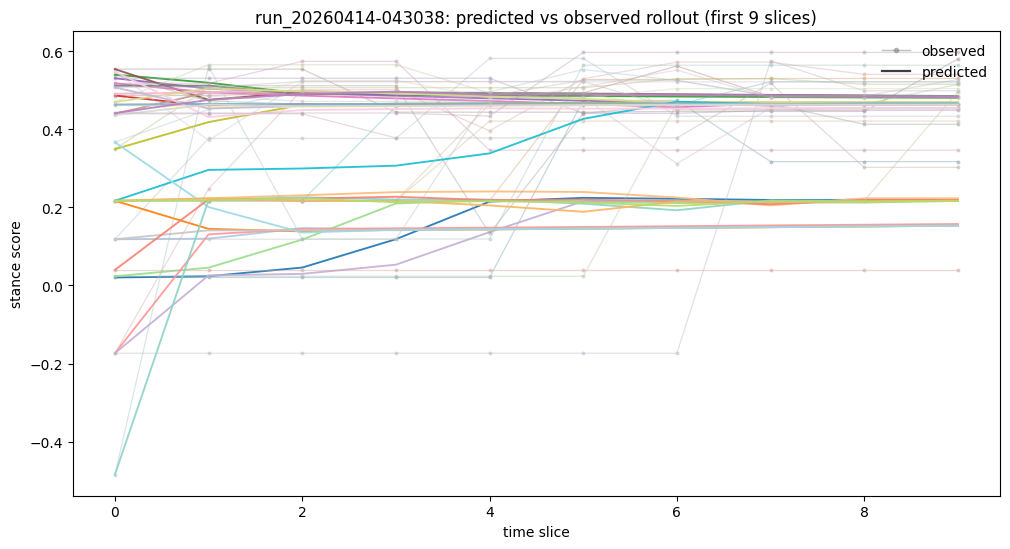

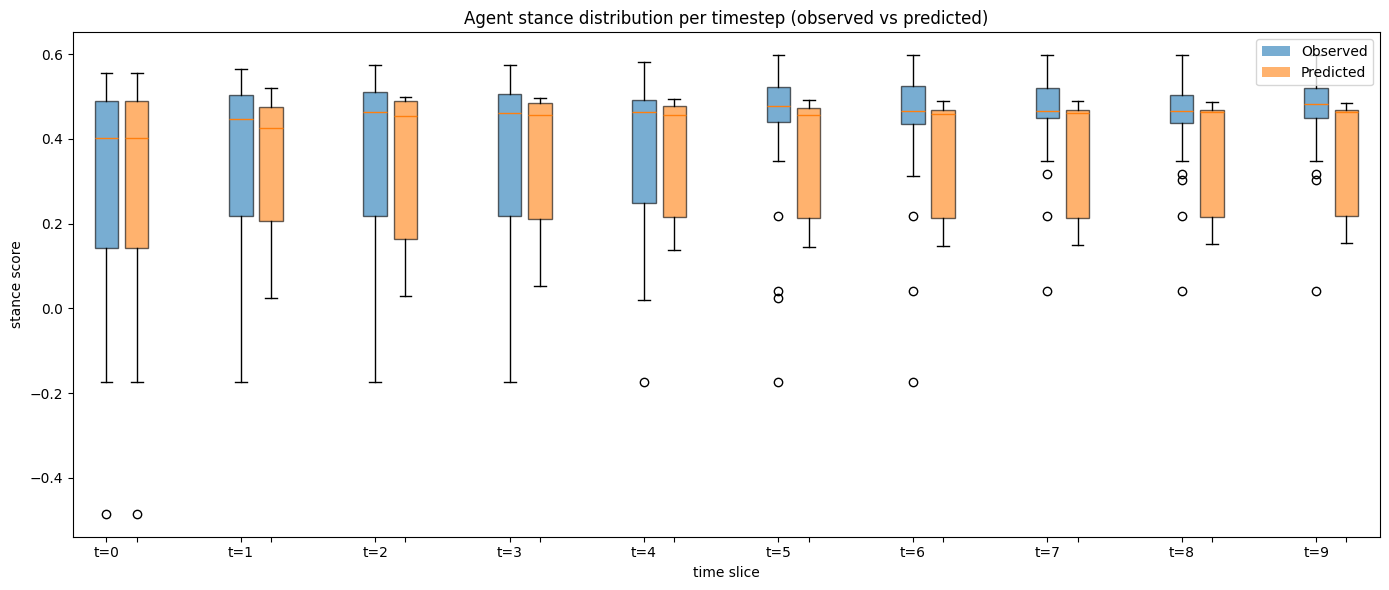

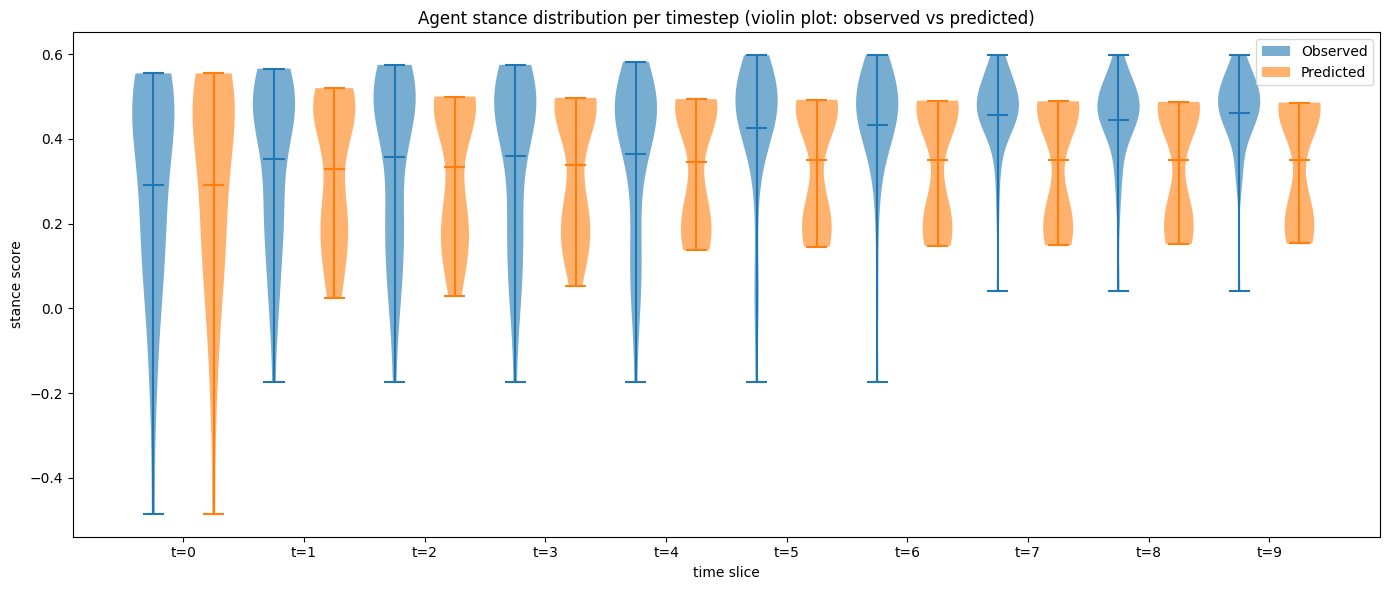

Per-trajectory diagnostics for model: homophily_fj


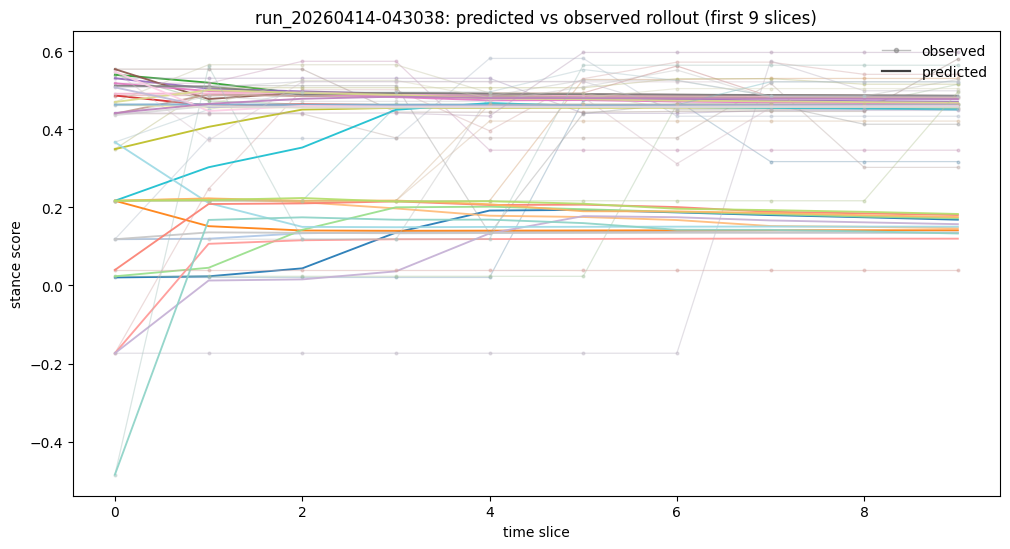

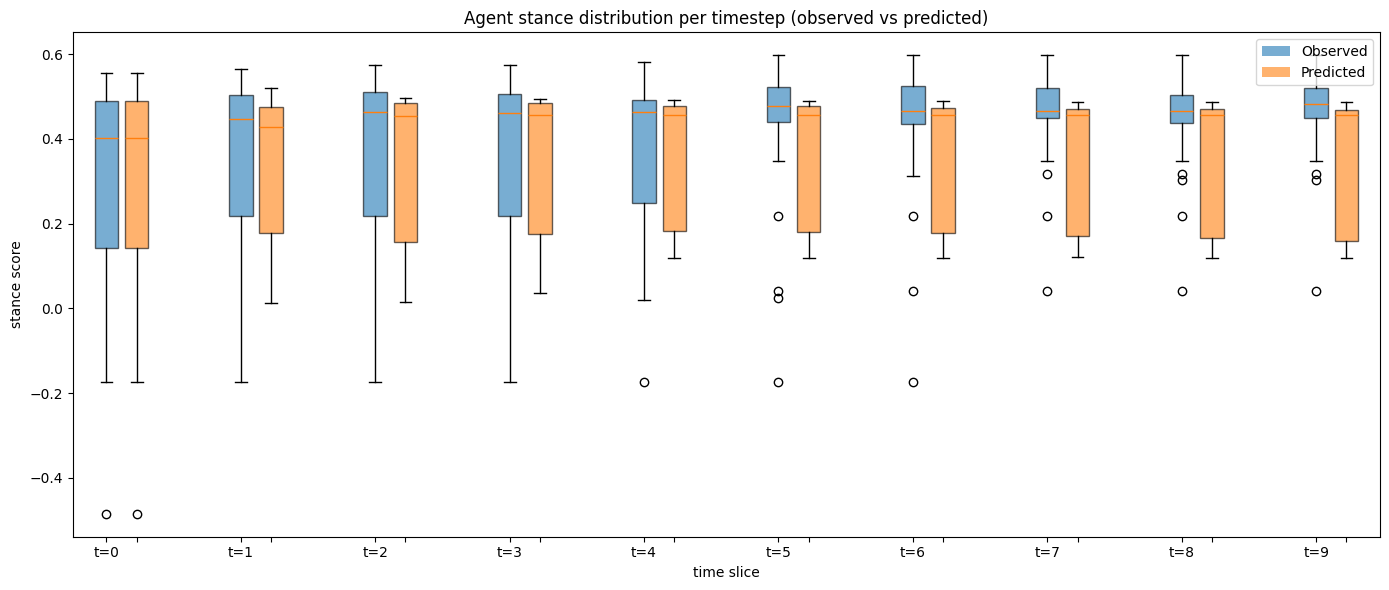

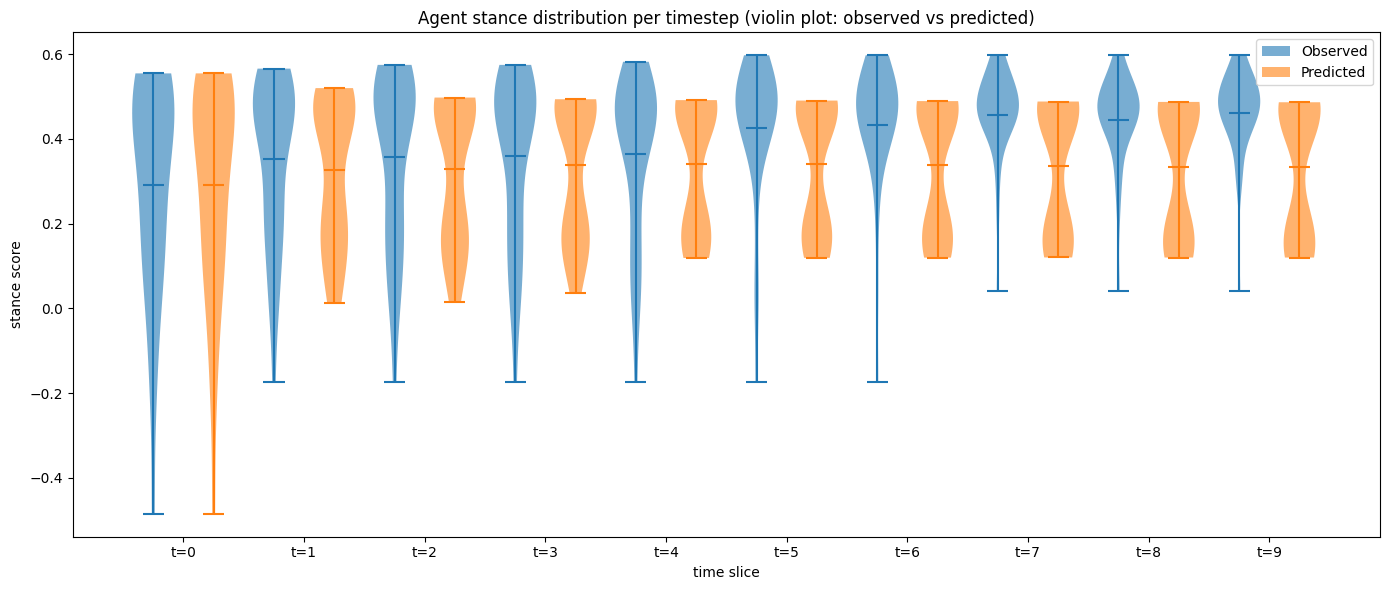

Per-trajectory diagnostics for model: homophily_bias


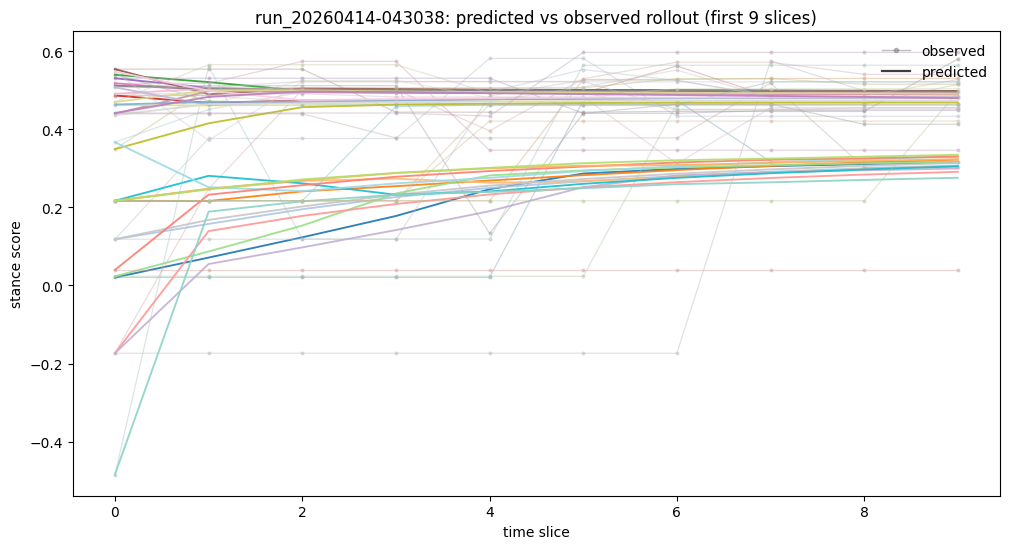

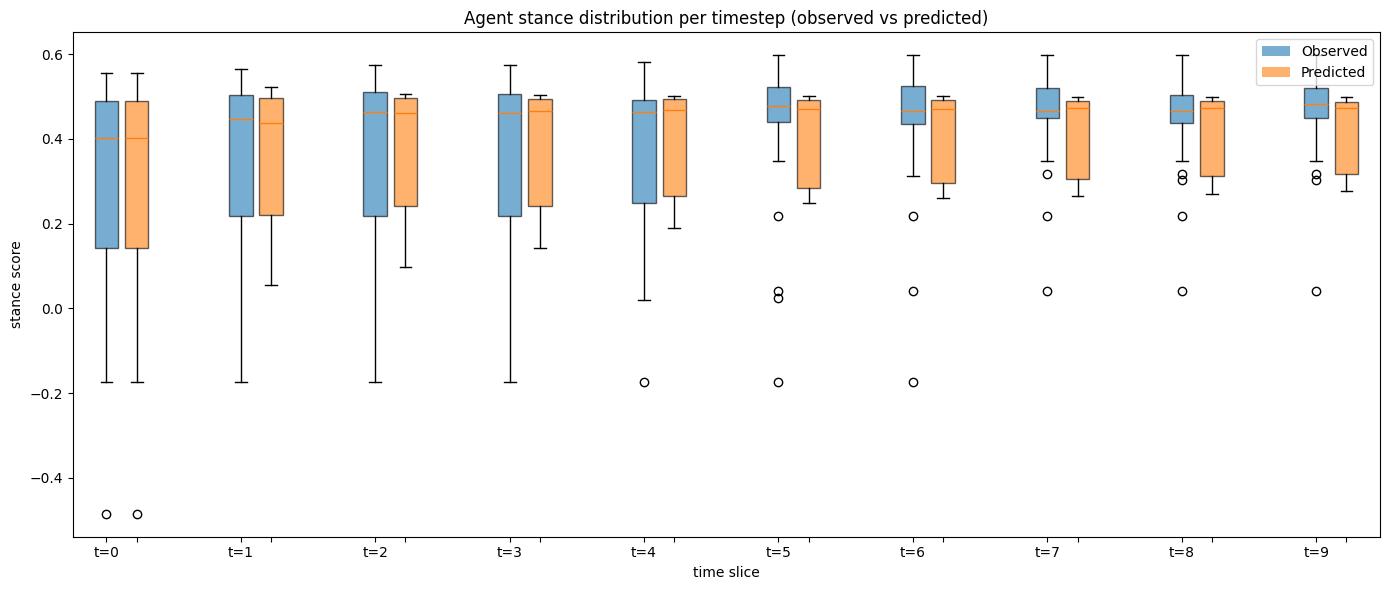

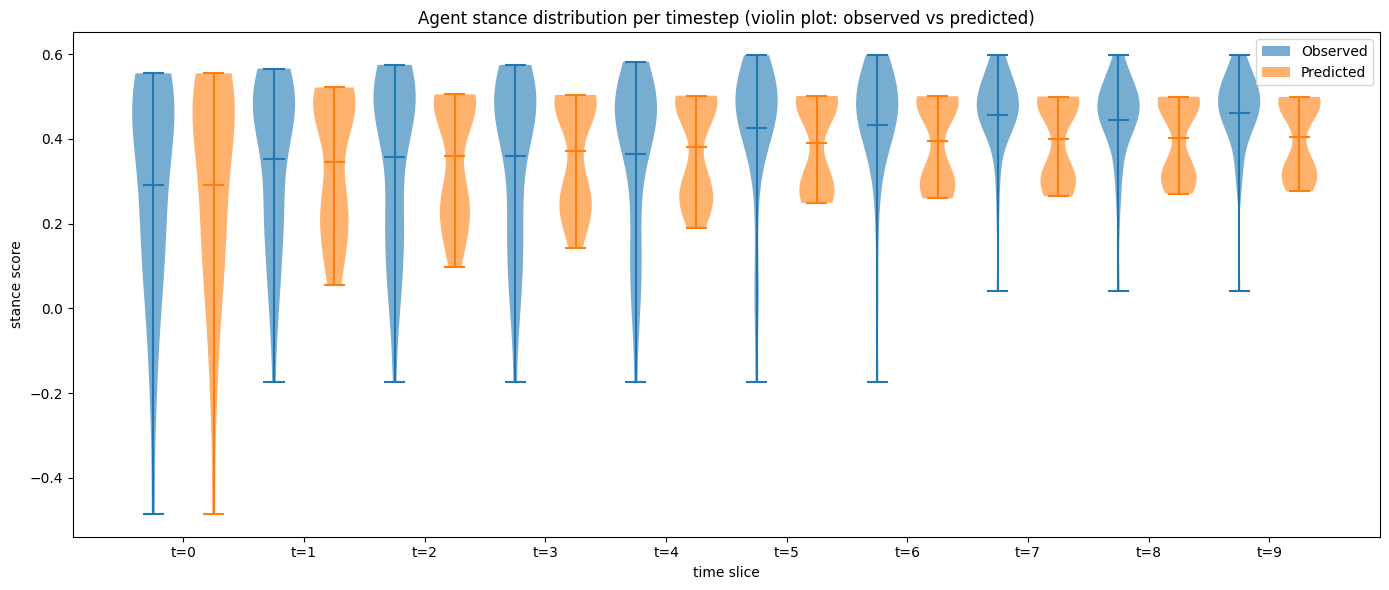

In [4]:
TEST_RUN_DIRS = sorted([p for p in TEST_ROOT.iterdir() if p.is_dir()])
TEST_DATA = {r.name: load_run_data(r) for r in TEST_RUN_DIRS}
TEST_TRAJ_AND_MASK = {
    rn: build_run_trajectory(
        d,
        GLOBAL_AGENT_IDS,
        target_agent_fraction=PARAMS['target_agent_fraction'],
        return_post_mask=True,
        constrain_messages=PARAMS['constrain_messages'],
    )
    for rn, d in TEST_DATA.items()
}
TEST_TRAJ = {rn: tm[0] for rn, tm in TEST_TRAJ_AND_MASK.items()}
TEST_POST_MASK = {rn: tm[1] for rn, tm in TEST_TRAJ_AND_MASK.items()}
TEST_NEIGHBORS = {rn: build_neighbors_index(d, GLOBAL_AGENT_IDS) for rn, d in TEST_DATA.items()}
TEST_RUN_NAMES = sorted(TEST_TRAJ.keys())

print('Validation runs found:', len(TEST_RUN_NAMES))
for rn in TEST_RUN_NAMES:
    print(rn, 'shape=', np.asarray(TEST_TRAJ[rn], dtype=float).shape)

TEST_DEGROOT = evaluate_validation_model_by_run(
    TEST_TRAJ,
    lambda _rn, observed: degroot_rollout_prediction(
        DEGROOT_W,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
    ),
)
TEST_FJ = evaluate_validation_model_by_run(
    TEST_TRAJ,
    lambda _rn, observed: friedkin_johnsen_rollout_prediction(
        FJ_W,
        FJ_BIAS,
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        BEST_FJ['lambda1'],
        BEST_FJ['lambda2'],
    ),
)
TEST_HOMO = evaluate_validation_model_by_run(
    TEST_TRAJ,
    lambda _rn, observed: rollout_fg_homophily(
        HOMO_FIT['W'],
        HOMO_FIT['gamma'],
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
    ),
)
TEST_HOMO_FJ = evaluate_validation_model_by_run(
    TEST_TRAJ,
    lambda _rn, observed: rollout_fg_fj_homophily(
        HOMO_FJ_FIT['W'],
        HOMO_FJ_FIT['gamma'],
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        lambda_homophily=HOMO_FJ_FIT['lambda_homophily'],
    ),
)
TEST_HOMO_BIAS = evaluate_validation_model_by_run(
    TEST_TRAJ,
    lambda _rn, observed: rollout_fg_fj_bias_homophily(
        HOMO_BIAS_FIT['W'],
        HOMO_BIAS_FIT['gamma'],
        np.asarray(observed, dtype=float)[0],
        PARAMS['rollout_horizon_cap'],
        bias=HOMO_BIAS_FIT['bias'],
        lambda1=HOMO_BIAS_FIT['lambda1'],
        lambda2=HOMO_BIAS_FIT['lambda2'],
    ),
)

VALIDATION_CURVE_HORIZON = min(
    TEST_DEGROOT['mean_true_stack'].shape[1],
    TEST_FJ['mean_true_stack'].shape[1],
    TEST_HOMO['mean_true_stack'].shape[1],
    TEST_HOMO_FJ['mean_true_stack'].shape[1],
    TEST_HOMO_BIAS['mean_true_stack'].shape[1],
)

print('Validation curve horizon (shared):', VALIDATION_CURVE_HORIZON)

print('Degroot')
plot_mean_per_timestep(
    TEST_DEGROOT['mean_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_DEGROOT['mean_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TEST_DEGROOT['var_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_DEGROOT['var_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TEST_DEGROOT['wasserstein_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)

print('Friedkin-Johnsen')
plot_mean_per_timestep(
    TEST_FJ['mean_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_FJ['mean_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TEST_FJ['var_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_FJ['var_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TEST_FJ['wasserstein_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)

print('Homophily')
plot_mean_per_timestep(
    TEST_HOMO['mean_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_HOMO['mean_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TEST_HOMO['var_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_HOMO['var_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TEST_HOMO['wasserstein_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)

print('Homophily + FJ')
plot_mean_per_timestep(
    TEST_HOMO_FJ['mean_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_HOMO_FJ['mean_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TEST_HOMO_FJ['var_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_HOMO_FJ['var_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TEST_HOMO_FJ['wasserstein_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)

print('Homophily + bias')
plot_mean_per_timestep(
    TEST_HOMO_BIAS['mean_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_HOMO_BIAS['mean_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_variance_per_timestep(
    TEST_HOMO_BIAS['var_true_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
    TEST_HOMO_BIAS['var_pred_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)
plot_wasserstein_distance_per_timestep(
    TEST_HOMO_BIAS['wasserstein_stack'].mean(axis=0)[:VALIDATION_CURVE_HORIZON],
)

test_summary = pd.DataFrame([
    {
        'model': 'degroot',
        'transition_mse_mean': TEST_DEGROOT['transition_mse_mean'],
        'mean_curve_abs_error': TEST_DEGROOT['mean_curve_abs_error'],
        'var_curve_abs_error': TEST_DEGROOT['var_curve_abs_error'],
        'wasserstein_curve_mean': TEST_DEGROOT['wasserstein_curve_mean'],
    },
    {
        'model': 'friedkin_johnsen',
        'transition_mse_mean': TEST_FJ['transition_mse_mean'],
        'mean_curve_abs_error': TEST_FJ['mean_curve_abs_error'],
        'var_curve_abs_error': TEST_FJ['var_curve_abs_error'],
        'wasserstein_curve_mean': TEST_FJ['wasserstein_curve_mean'],
    },
    {
        'model': 'homophily',
        'transition_mse_mean': TEST_HOMO['transition_mse_mean'],
        'mean_curve_abs_error': TEST_HOMO['mean_curve_abs_error'],
        'var_curve_abs_error': TEST_HOMO['var_curve_abs_error'],
        'wasserstein_curve_mean': TEST_HOMO['wasserstein_curve_mean'],
    },
    {
        'model': 'homophily_fj',
        'transition_mse_mean': TEST_HOMO_FJ['transition_mse_mean'],
        'mean_curve_abs_error': TEST_HOMO_FJ['mean_curve_abs_error'],
        'var_curve_abs_error': TEST_HOMO_FJ['var_curve_abs_error'],
        'wasserstein_curve_mean': TEST_HOMO_FJ['wasserstein_curve_mean'],
    },
    {
        'model': 'homophily_bias',
        'transition_mse_mean': TEST_HOMO_BIAS['transition_mse_mean'],
        'mean_curve_abs_error': TEST_HOMO_BIAS['mean_curve_abs_error'],
        'var_curve_abs_error': TEST_HOMO_BIAS['var_curve_abs_error'],
        'wasserstein_curve_mean': TEST_HOMO_BIAS['wasserstein_curve_mean'],
    },
])
print(test_summary)

validation_eval_map = {
    'degroot': (TEST_DEGROOT, 1),
    'friedkin_johnsen': (TEST_FJ, 3),
    'homophily': (TEST_HOMO, 1),
    'homophily_fj': (TEST_HOMO_FJ, 2),
    'homophily_bias': (TEST_HOMO_BIAS, 4),
}

validation_ablation_rows = []
for model_name, (eval_result, num_params) in validation_eval_map.items():
    y_true_flat, y_pred_flat = flatten_eval_result(eval_result)
    mean_stats = compute_mean_prediction_error(y_true_flat, y_pred_flat, num_params=num_params)
    max_stats = compute_max_prediction_error(y_true_flat, y_pred_flat, num_params=num_params)
    validation_ablation_rows.append({
        'model': model_name,
        'num_params': num_params,
        'mean_abs_error': mean_stats['mean_error'],
        'max_abs_error': max_stats['max_error'],
        'mse_aic': mean_stats['aic'],
        'mse_bic': mean_stats['bic'],
        'mae_aic': max_stats['aic'],
        'mae_bic': max_stats['bic'],
    })

validation_ablation_aic_bic = pd.DataFrame(validation_ablation_rows).sort_values('mse_aic').reset_index(drop=True)
print(validation_ablation_aic_bic)

run_id = max(TEST_RUN_NAMES, key=lambda rn: np.asarray(TEST_TRAJ[rn], dtype=float).shape[0])
plot_horizon = min(
    10,
    np.asarray(TEST_TRAJ[run_id], dtype=float).shape[0] - 1,
    np.asarray(TEST_DEGROOT['per_run'][run_id]['predicted'], dtype=float).shape[0] - 1,
)

print('Validation sample run:', run_id)
print('Plot horizon (slices):', plot_horizon)
plot_observed_trajectories(run_id, TEST_TRAJ[run_id], GLOBAL_AGENT_IDS, plot_horizon)

per_model_predictions = [
    ('degroot', TEST_DEGROOT['per_run'][run_id]['predicted']),
    ('friedkin_johnsen', TEST_FJ['per_run'][run_id]['predicted']),
    ('homophily', TEST_HOMO['per_run'][run_id]['predicted']),
    ('homophily_fj', TEST_HOMO_FJ['per_run'][run_id]['predicted']),
    ('homophily_bias', TEST_HOMO_BIAS['per_run'][run_id]['predicted']),
]

for model_name, predicted_curve in per_model_predictions:
    print(f'Per-trajectory diagnostics for model: {model_name}')
    plot_predicted_vs_observed(
        run_id,
        TEST_TRAJ[run_id],
        predicted_curve,
        GLOBAL_AGENT_IDS,
        plot_horizon,
    )
    observed_aligned, predicted_aligned = align_rollout_pair(
        np.asarray(TEST_TRAJ[run_id], dtype=float),
        np.asarray(predicted_curve, dtype=float),
    )
    observed_aligned = observed_aligned[: plot_horizon + 1]
    predicted_aligned = predicted_aligned[: plot_horizon + 1]
    plot_box_per_timestep(observed_aligned, predicted_aligned)
    plot_violin_per_timestep(observed_aligned, predicted_aligned)